## Confronto Euclidea vs DCE

In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

project_root = Path.cwd().resolve()

# Il notebook è nella cartella examples/
if project_root.name == "examples":
    project_root = project_root.parent


# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

euclidean_path = project_root / "results" / "brt" / "euclidean.npz"
dce_path = project_root / "results" / "brt" / "dce1s.npz"

print("Euclidean:", euclidean_path)
print("DCE:      ", dce_path)

assert euclidean_path.exists(), f"File not found: {euclidean_path}"
assert dce_path.exists(), f"File not found: {dce_path}"


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

euclidean = np.load(euclidean_path, allow_pickle=False)
dce = np.load(dce_path, allow_pickle=False)


Euclidean: /home/alessio-grisorio/TESI/hj_reachability/results/brt/euclidean.npz
DCE:       /home/alessio-grisorio/TESI/hj_reachability/results/brt/dce1s.npz


In [4]:
# ------------------------------------------------------------
# Coordinate vectors
# ------------------------------------------------------------

coordinate_names = [
    "x_rel",
    "y_rel",
    "theta_rel",
    "v_H",
    "delta_E",
    "v_E",
]

for name in coordinate_names:
    a = euclidean[name]
    b = dce[name]

    assert a.shape == b.shape, (
        f"Different shape for {name}: "
        f"{a.shape} != {b.shape}"
    )

    assert np.allclose(a, b), (
        f"Different grid values for {name}"
    )

print("Euclidean and DCE use the same grid.")


x_rel = euclidean["x_rel"]
y_rel = euclidean["y_rel"]
theta_rel = euclidean["theta_rel"]
v_H = euclidean["v_H"]
delta_E = euclidean["delta_E"]
v_E = euclidean["v_E"]

print("\nGrid:")
print("x_rel:    ", x_rel)
print("y_rel:    ", y_rel)
print("theta_rel:", theta_rel)
print("v_H:      ", v_H)
print("delta_E:  ", delta_E)
print("v_E:      ", v_E)

Euclidean and DCE use the same grid.

Grid:
x_rel:     [-8.        -7.        -6.        -5.        -4.        -3.
 -1.9999999 -1.0000002  0.         1.0000002  1.9999999  3.
  4.         5.         6.         7.         8.         9.
 10.        11.        12.        13.        14.        15.
 16.        17.       ]
y_rel:     [-6.        -5.        -4.        -3.        -1.9999998 -1.
  0.         1.0000002  2.         3.         4.         5.
  6.       ]
theta_rel: [-7.8539819e-01 -6.7319840e-01 -5.6099874e-01 -4.4879895e-01
 -3.3659923e-01 -2.2439948e-01 -1.1219969e-01  1.8626451e-08
  1.1219978e-01  2.2439955e-01  3.3659926e-01  4.4879904e-01
  5.6099880e-01  6.7319852e-01  7.8539819e-01]
v_H:       [ 1.         2.4285715  3.857143   5.2857146  6.714286   8.142858
  9.571429  11.       ]
delta_E:   [-0.2617994  -0.23561946 -0.20943952 -0.18325958 -0.15707964 -0.1308997
 -0.10471976 -0.07853982 -0.05235988 -0.02617992  0.          0.02617994
  0.05235989  0.07853983  0.10471976  0

In [5]:
def nearest_index(vector, target):
    return int(np.argmin(np.abs(vector - target)))


# ------------------------------------------------------------
# Fixed angles
# ------------------------------------------------------------

theta_target = 0.0
delta_target = 0.0

i_theta = nearest_index(theta_rel, theta_target)
i_delta = nearest_index(delta_E, delta_target)


# ------------------------------------------------------------
# Requested speeds
# ------------------------------------------------------------

v_slow_target = 4.0
v_fast_target = 8.0

i_vH_slow = nearest_index(v_H, v_slow_target)
i_vH_fast = nearest_index(v_H, v_fast_target)

i_vE_slow = nearest_index(v_E, v_slow_target)
i_vE_fast = nearest_index(v_E, v_fast_target)


# Actual values used
theta_value = theta_rel[i_theta]
delta_value = delta_E[i_delta]

vH_slow = v_H[i_vH_slow]
vH_fast = v_H[i_vH_fast]

vE_slow = v_E[i_vE_slow]
vE_fast = v_E[i_vE_fast]


print(f"theta_rel = {theta_value:.6f} rad")
print(f"delta_E   = {delta_value:.6f} rad")

print("\nClosing case: Ego faster than Human")
print(f"v_H = {vH_slow:.3f} m/s")
print(f"v_E = {vE_fast:.3f} m/s")

print("\nOpening case: Human faster than Ego")
print(f"v_H = {vH_fast:.3f} m/s")
print(f"v_E = {vE_slow:.3f} m/s")

theta_rel = 0.000000 rad
delta_E   = 0.000000 rad

Closing case: Ego faster than Human
v_H = 3.857 m/s
v_E = 8.143 m/s

Opening case: Human faster than Ego
v_H = 8.143 m/s
v_E = 3.857 m/s


In [6]:
V0_euclidean = euclidean["V0"]
V0_dce = dce["V0"]


# ------------------------------------------------------------
# 1. Euclidean
#
# Ego faster than Human.
# For the Euclidean metric the selected velocities do not
# affect V0, but we use the same closing configuration as
# the first DCE case for clarity.
# ------------------------------------------------------------

slice_euclidean = V0_euclidean[
    :,
    :,
    i_theta,
    i_vH_slow,
    i_delta,
    i_vE_fast,
]


# ------------------------------------------------------------
# 2. DCE - CLOSING
#
# Human is in front (x_rel > 0)
# Ego is faster:
#
#       v_E > v_H
#
# Therefore Ego approaches Human.
# ------------------------------------------------------------

slice_dce_closing = V0_dce[
    :,
    :,
    i_theta,
    i_vH_slow,
    i_delta,
    i_vE_fast,
]


# ------------------------------------------------------------
# 3. DCE - OPENING
#
# Same relative positions, but:
#
#       v_H > v_E
#
# Therefore Human moves away from Ego.
# ------------------------------------------------------------

slice_dce_opening = V0_dce[
    :,
    :,
    i_theta,
    i_vH_fast,
    i_delta,
    i_vE_slow,
]


print("Slice shape:", slice_euclidean.shape)

Slice shape: (26, 13)


In [7]:
# ------------------------------------------------------------
# Keep only x_rel >= 0
# ------------------------------------------------------------

front_mask = x_rel >= 0.0

x_plot = x_rel[front_mask]

euclidean_plot = slice_euclidean[front_mask, :]
dce_closing_plot = slice_dce_closing[front_mask, :]
dce_opening_plot = slice_dce_opening[front_mask, :]


# Same mesh for all three plots
X, Y = np.meshgrid(
    x_plot,
    y_rel,
    indexing="ij",
)

print(
    f"Displayed x_rel range: "
    f"[{x_plot.min():.1f}, {x_plot.max():.1f}] m"
)

print(
    f"Displayed y_rel range: "
    f"[{y_rel.min():.1f}, {y_rel.max():.1f}] m"
)

Displayed x_rel range: [0.0, 17.0] m
Displayed y_rel range: [-6.0, 6.0] m


In [8]:
# ------------------------------------------------------------
# Numerical comparison
# ------------------------------------------------------------

difference_opening = (
    dce_opening_plot - euclidean_plot
)

difference_closing = (
    dce_closing_plot - euclidean_plot
)


print("DCE opening - Euclidean")
print(
    f"  min = {difference_opening.min(): .6f}"
)
print(
    f"  max = {difference_opening.max(): .6f}"
)
print(
    f"  mean absolute difference = "
    f"{np.mean(np.abs(difference_opening)):.6f}"
)


print("\nDCE closing - Euclidean")
print(
    f"  min = {difference_closing.min(): .6f}"
)
print(
    f"  max = {difference_closing.max(): .6f}"
)
print(
    f"  mean = {difference_closing.mean(): .6f}"
)

DCE opening - Euclidean
  min = -0.185107
  max =  0.000000
  mean absolute difference = 0.003331

DCE closing - Euclidean
  min = -4.269848
  max =  0.000000
  mean = -2.365895


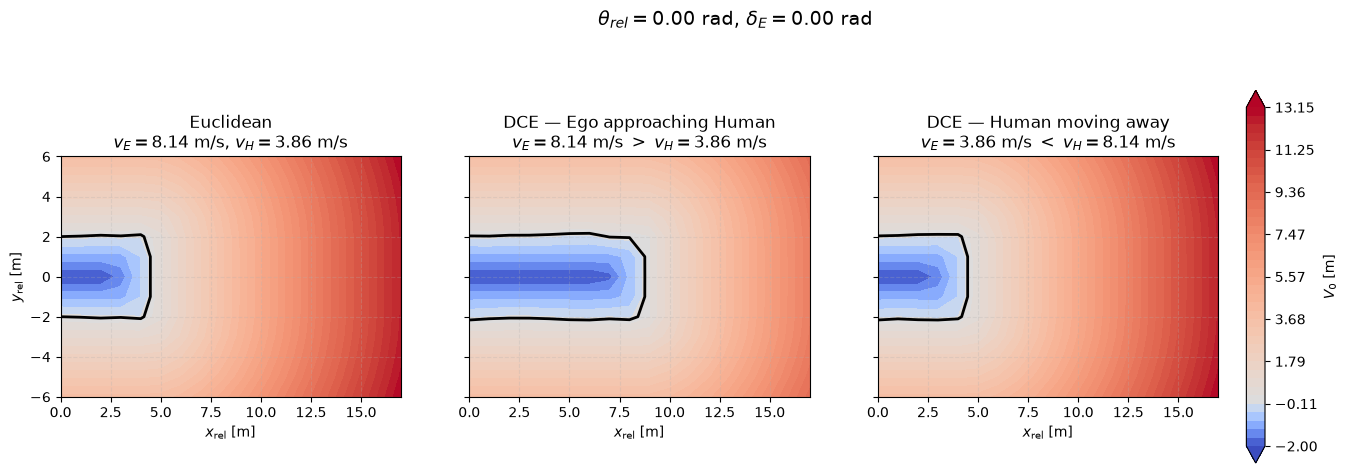

In [9]:
# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------

all_values = np.concatenate([
    euclidean_plot.ravel(),
    dce_closing_plot.ravel(),
    dce_opening_plot.ravel(),
])

vmin = float(all_values.min())
vmax = float(all_values.max())

levels = np.linspace(
    vmin,
    vmax,
    41,
)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax,
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    sharex=True,
    sharey=True,
)

data = [
    euclidean_plot,
    dce_closing_plot,
    dce_opening_plot,
]

titles = [
    (
        "Euclidean\n"
        rf"$v_E={vE_fast:.2f}$ m/s, "
        rf"$v_H={vH_slow:.2f}$ m/s"
    ),
    (
        "DCE — Ego approaching Human\n"
        rf"$v_E={vE_fast:.2f}$ m/s $>$ "
        rf"$v_H={vH_slow:.2f}$ m/s"
    ),
    (
        "DCE — Human moving away\n"
        rf"$v_E={vE_slow:.2f}$ m/s $<$ "
        rf"$v_H={vH_fast:.2f}$ m/s"
    ),
]


contour = None

for ax, Z, title in zip(
    axes,
    data,
    titles,
):
    contour = ax.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap="coolwarm",
        norm=norm,
        extend="both",
    )

    # Zero level
    ax.contour(
        X,
        Y,
        Z,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )

    ax.set_title(title)

    ax.set_xlabel(
        r"$x_{\mathrm{rel}}$ [m]"
    )

    ax.set_aspect("equal")

    ax.grid(
        alpha=0.25,
        linestyle="--",
    )


axes[0].set_ylabel(
    r"$y_{\mathrm{rel}}$ [m]"
)


fig.suptitle(
    (
        rf"$\theta_{{rel}}={theta_value:.2f}$ rad, "
        rf"$\delta_E={delta_value:.2f}$ rad"
    ),
    fontsize=14,
)


cbar = fig.colorbar(
    contour,
    ax=axes,
    shrink=0.88,
    pad=0.02,
)

cbar.set_label(
    r"$V_0$ [m]"
)

plt.show()